<a href="https://colab.research.google.com/github/yejxjj/2026-1_CV/blob/main/HW3_%EC%8B%A4%ED%97%98C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ExponentialLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import math
from dataclasses import dataclass, field
from typing import Dict, List, Optional
from IPython.display import display

plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 실험 설정값

@dataclass
class ExpCConfig:
    # 데이터
    input_dim: int = 28 * 28      # Fashion-MNIST 입력 차원
    num_classes: int = 10
    batch_size: int = 128         # Fashion-MNIST 크기 고려해 적절히 설정

    # 학습
    n_epochs: int = 20            # 가이드: 20~50, 18개 조합 시간 고려
    momentum_value: float = 0.9
    scheduler_gamma: float = 0.9  # ExponentialLR 감마

    # 비교 대상
    lr_candidates: tuple = (0.1, 0.01, 0.001)
    optimizer_names: tuple = ("SGD", "SGD+Momentum", "Adam")
    scheduler_options: tuple = (True, False)

    # 분석 임계값
    convergence_acc: float = 0.85    # Fashion-MNIST 수렴 판정용
    stability_window_frac: float = 0.5

    seed: int = 50

CFG = ExpCConfig()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {DEVICE}")


def lock_seed(seed: int):

    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

lock_seed(CFG.seed)

사용 디바이스: cuda


In [ ]:
# Fashion-MNIST 데이터셋 사용
# 28x28 흑백 의류 이미지, 60,000 train + 10,000 test, 10 클래스

def load_fashion_mnist(cfg: ExpCConfig):
    # 픽셀값 [-1, 1] 정규화
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,))
    ])

    train_ds = datasets.FashionMNIST(
        root="./data", train=True, download=True, transform=transform
    )
    test_ds = datasets.FashionMNIST(
        root="./data", train=False, download=True, transform=transform
    )

    pin = torch.cuda.is_available()
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size,
                              shuffle=True, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size,
                             shuffle=False, pin_memory=pin)

    return train_loader, test_loader


train_loader, test_loader = load_fashion_mnist(CFG)
print(f"학습 샘플: {len(train_loader.dataset)}, 테스트 샘플: {len(test_loader.dataset)}")
print(f"배치 수 (학습): {len(train_loader)}, 배치 수 (테스트): {len(test_loader)}")

학습 샘플: 60000, 테스트 샘플: 10000
배치 수 (학습): 469, 배치 수 (테스트): 79


In [ ]:
# 모델 정의

class FashionMLP(nn.Module):

    def __init__(self, in_dim: int, n_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # (B, 1, 28, 28) → (B, 784)
        h1 = self.relu1(self.fc1(x))
        h2 = self.relu2(self.fc2(h1))
        return self.fc3(h2)


def build_model(cfg: ExpCConfig) -> FashionMLP:
    return FashionMLP(cfg.input_dim, cfg.num_classes).to(DEVICE)


# Optimizer 팩토리: 이름과 학습률을 받아 적절한 optimizer 객체 반환
def make_optimizer(name: str, params, lr: float, momentum: float = 0.9):
    if name == "SGD":
        return optim.SGD(params, lr=lr)
    elif name == "SGD+Momentum":
        return optim.SGD(params, lr=lr, momentum=momentum)
    elif name == "Adam":
        return optim.Adam(params, lr=lr)
    else:
        raise ValueError(f"알 수 없는 optimizer: {name}")

In [ ]:
# 학습 결과 컨테이너
# 손실/정확도/학습률 + epoch별 평균 gradient norm + 레이어별 gradient norm 함께 기록

@dataclass
class ExpCRecord:
    train_loss: List[float] = field(default_factory=list)
    train_acc: List[float] = field(default_factory=list)
    val_loss: List[float] = field(default_factory=list)
    val_acc: List[float] = field(default_factory=list)
    lr_track: List[float] = field(default_factory=list)
    grad_norm_total: List[float] = field(default_factory=list)
    grad_norm_per_layer: Dict[str, List[float]] = field(
        default_factory=lambda: {"fc1": [], "fc2": [], "fc3": []}
    )
    convergence_epoch: Optional[int] = None
    elapsed_sec: float = 0.0


# 손실 함수는 외부에서 한 번만 생성
GLOBAL_CRITERION = nn.CrossEntropyLoss()


def train_single_epoch(model, loader, criterion, optimizer):
    model.train()
    sum_loss, n_correct, n_total = 0.0, 0, 0

    grad_acc = {"fc1": 0.0, "fc2": 0.0, "fc3": 0.0, "total": 0.0}
    n_batches = 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()

        # gradient L2 norm 계산 (epoch 평균을 위해 누적)
        with torch.no_grad():
            total_sq = 0.0
            for layer_name in ["fc1", "fc2", "fc3"]:
                layer = getattr(model, layer_name)
                if layer.weight.grad is not None:
                    g = layer.weight.grad.norm().item()
                    grad_acc[layer_name] += g
                    total_sq += g ** 2
            grad_acc["total"] += math.sqrt(total_sq)

        optimizer.step()

        sum_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)
        n_correct += (preds == y_batch).sum().item()
        n_total += y_batch.size(0)
        n_batches += 1

    avg_loss = sum_loss / n_total
    avg_acc = n_correct / n_total
    avg_grad = {k: v / max(n_batches, 1) for k, v in grad_acc.items()}

    return avg_loss, avg_acc, avg_grad


@torch.no_grad()
def eval_single_epoch(model, loader, criterion):

    model.eval()
    sum_loss, n_correct, n_total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        sum_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)
        n_correct += (preds == y_batch).sum().item()
        n_total += y_batch.size(0)
    return sum_loss / n_total, n_correct / n_total


def run_one_experiment(optimizer_name: str, lr: float, use_scheduler: bool,
                       cfg: ExpCConfig) -> ExpCRecord:
    lock_seed(cfg.seed)

    model = build_model(cfg)
    optimizer = make_optimizer(optimizer_name, model.parameters(), lr, cfg.momentum_value)
    scheduler = ExponentialLR(optimizer, gamma=cfg.scheduler_gamma) if use_scheduler else None

    record = ExpCRecord()
    t_start = time.time()

    for epoch in range(1, cfg.n_epochs + 1):
        # 현재 lr 기록 (scheduler step 전 시점)
        record.lr_track.append(optimizer.param_groups[0]["lr"])

        # 학습 + 검증
        tr_loss, tr_acc, grad_avg = train_single_epoch(
            model, train_loader, GLOBAL_CRITERION, optimizer
        )
        va_loss, va_acc = eval_single_epoch(model, test_loader, GLOBAL_CRITERION)

        # 기록
        record.train_loss.append(tr_loss)
        record.train_acc.append(tr_acc)
        record.val_loss.append(va_loss)
        record.val_acc.append(va_acc)
        record.grad_norm_total.append(grad_avg["total"])
        for ln in ["fc1", "fc2", "fc3"]:
            record.grad_norm_per_layer[ln].append(grad_avg[ln])

        # 수렴 epoch 자동 판정
        if record.convergence_epoch is None and va_acc >= cfg.convergence_acc:
            record.convergence_epoch = epoch

        # scheduler 한 step (epoch 단위)
        if scheduler is not None:
            scheduler.step()

    record.elapsed_sec = time.time() - t_start
    return record

In [ ]:
# 메인 실험: 3 Optimizer × 3 LR × 2 Scheduler = 18개 조합

all_records: Dict[tuple, ExpCRecord] = {}

print("="*75)
print("실험 C 메인: 18개 조합 학습 시작 (Fashion-MNIST)")
print("="*75)

total_start = time.time()

for use_sched in CFG.scheduler_options:
    sched_tag = "Sched ON " if use_sched else "Sched OFF"
    for opt_name in CFG.optimizer_names:
        for lr in CFG.lr_candidates:
            print(f"\n[{opt_name:<14} | lr={lr:<6} | {sched_tag}]")

            rec = run_one_experiment(opt_name, lr, use_sched, CFG)
            all_records[(opt_name, lr, use_sched)] = rec

            final_va = rec.val_acc[-1] * 100
            min_vl = min(rec.val_loss)
            conv = rec.convergence_epoch if rec.convergence_epoch else "미수렴"
            print(f"  → 최종 Val Acc {final_va:.2f}%, "
                  f"Loss 최솟값 {min_vl:.4f}, 수렴 epoch: {conv} "
                  f"(소요 {rec.elapsed_sec:.1f}s)")

total_elapsed = time.time() - total_start
print("\n" + "="*75)
print(f"모든 실험 완료 (총 소요 시간: {total_elapsed/60:.1f}분)")
print("="*75)

실험 C 메인: 18개 조합 학습 시작 (Fashion-MNIST)

[SGD            | lr=0.1    | Sched ON ]
  → 최종 Val Acc 88.82%, Loss 최솟값 0.3174, 수렴 epoch: 3 (소요 67.2s)

[SGD            | lr=0.01   | Sched ON ]
  → 최종 Val Acc 83.64%, Loss 최솟값 0.4522, 수렴 epoch: 미수렴 (소요 65.2s)

[SGD            | lr=0.001  | Sched ON ]
  → 최종 Val Acc 72.31%, Loss 최솟값 0.8146, 수렴 epoch: 미수렴 (소요 66.0s)

[SGD+Momentum   | lr=0.1    | Sched ON ]
  → 최종 Val Acc 89.27%, Loss 최솟값 0.3356, 수렴 epoch: 3 (소요 68.0s)

[SGD+Momentum   | lr=0.01   | Sched ON ]
  → 최종 Val Acc 88.57%, Loss 최솟값 0.3169, 수렴 epoch: 3 (소요 69.6s)

[SGD+Momentum   | lr=0.001  | Sched ON ]
  → 최종 Val Acc 83.70%, Loss 최솟값 0.4534, 수렴 epoch: 미수렴 (소요 67.3s)

[Adam           | lr=0.1    | Sched ON ]
  → 최종 Val Acc 19.94%, Loss 최솟값 1.7293, 수렴 epoch: 미수렴 (소요 68.2s)

[Adam           | lr=0.01   | Sched ON ]
  → 최종 Val Acc 88.74%, Loss 최솟값 0.3619, 수렴 epoch: 3 (소요 68.1s)

[Adam           | lr=0.001  | Sched ON ]
  → 최종 Val Acc 89.26%, Loss 최솟값 0.3150, 수렴 epoch: 2 (소요 67.9s)

[SGD    

In [ ]:
# 정량 비교표 1: Optimizer × LR 매트릭스 (Scheduler OFF 기준)

def build_matrix_table(records, metric: str, use_sched: bool, cfg: ExpCConfig):

    matrix = {}
    for opt_name in cfg.optimizer_names:
        row = {}
        for lr in cfg.lr_candidates:
            key = (opt_name, lr, use_sched)
            if key not in records:
                row[f"lr={lr}"] = "N/A"
                continue
            rec = records[key]
            if metric == "final_acc":
                row[f"lr={lr}"] = f"{rec.val_acc[-1]*100:.2f}%"
            elif metric == "min_loss":
                row[f"lr={lr}"] = f"{min(rec.val_loss):.4f}"
            elif metric == "convergence":
                row[f"lr={lr}"] = (str(rec.convergence_epoch)
                                   if rec.convergence_epoch else f">{cfg.n_epochs}")
            elif metric == "stability":
                tail_start = int(cfg.n_epochs * cfg.stability_window_frac)
                tail = rec.val_loss[tail_start:]
                row[f"lr={lr}"] = f"{np.std(tail):.4f}" if len(tail) >= 2 else "N/A"
        matrix[opt_name] = row
    return pd.DataFrame(matrix).T


print("\n" + "="*75)
print("매트릭스 비교표 (Scheduler OFF) - Optimizer × Learning Rate")
print("="*75)

for metric_key, metric_label in [
    ("final_acc", "최종 정확도"),
    ("min_loss", "Loss 최솟값"),
    ("convergence", f"수렴 epoch (Val Acc {CFG.convergence_acc*100:.0f}% 돌파)"),
    ("stability", "안정성 (후반 Val Loss Std, 작을수록 좋음)")
]:
    print(f"\n[{metric_label}]")
    df = build_matrix_table(all_records, metric_key, use_sched=False, cfg=CFG)
    display(df)


매트릭스 비교표 (Scheduler OFF) - Optimizer × Learning Rate

[최종 정확도]


,lr=0.1,lr=0.01,lr=0.001
SGD,88.04%,85.83%,77.11%
SGD+Momentum,87.78%,88.71%,85.70%
Adam,10.00%,86.51%,88.85%



[Loss 최솟값]


,lr=0.1,lr=0.01,lr=0.001
SGD,0.3179,0.3963,0.6256
SGD+Momentum,0.3615,0.3221,0.3967
Adam,2.0838,0.3866,0.3305



[수렴 epoch (Val Acc 85% 돌파)]


,lr=0.1,lr=0.01,lr=0.001
SGD,3,16,>20
SGD+Momentum,3,3,15
Adam,>20,5,2



[안정성 (후반 Val Loss Std, 작을수록 좋음)]


,lr=0.1,lr=0.01,lr=0.001
SGD,0.0171,0.0121,0.0371
SGD+Momentum,0.0137,0.0139,0.0132
Adam,0.0033,0.0192,0.0129


In [ ]:
# 정량 비교표 2: Scheduler ON 매트릭스

print("\n" + "="*75)
print("매트릭스 비교표 (Scheduler ON, ExponentialLR gamma=0.9)")
print("="*75)

for metric_key, metric_label in [
    ("final_acc", "최종 정확도"),
    ("min_loss", "Loss 최솟값"),
    ("convergence", f"수렴 epoch (Val Acc {CFG.convergence_acc*100:.0f}% 돌파)"),
    ("stability", "안정성 (후반 Val Loss Std)")
]:
    print(f"\n[{metric_label}]")
    df = build_matrix_table(all_records, metric_key, use_sched=True, cfg=CFG)
    display(df)


매트릭스 비교표 (Scheduler ON, ExponentialLR gamma=0.9)

[최종 정확도]


,lr=0.1,lr=0.01,lr=0.001
SGD,88.82%,83.64%,72.31%
SGD+Momentum,89.27%,88.57%,83.70%
Adam,19.94%,88.74%,89.26%



[Loss 최솟값]


,lr=0.1,lr=0.01,lr=0.001
SGD,0.3174,0.4522,0.8146
SGD+Momentum,0.3356,0.3169,0.4534
Adam,1.7293,0.3619,0.3150



[수렴 epoch (Val Acc 85% 돌파)]


,lr=0.1,lr=0.01,lr=0.001
SGD,3,>20,>20
SGD+Momentum,3,3,>20
Adam,>20,3,2



[안정성 (후반 Val Loss Std)]


,lr=0.1,lr=0.01,lr=0.001
SGD,0.0040,0.0066,0.0344
SGD+Momentum,0.0052,0.0069,0.0069
Adam,0.0189,0.0114,0.0046


In [ ]:
# 정량 비교표 3: Scheduler 효과 정량화

def measure_scheduler_effect(records, cfg: ExpCConfig):
    rows = []
    for opt_name in cfg.optimizer_names:
        for lr in cfg.lr_candidates:
            off_key = (opt_name, lr, False)
            on_key = (opt_name, lr, True)
            if off_key not in records or on_key not in records:
                continue
            off_acc = records[off_key].val_acc[-1] * 100
            on_acc = records[on_key].val_acc[-1] * 100
            off_std = np.std(records[off_key].val_loss[cfg.n_epochs//2:])
            on_std = np.std(records[on_key].val_loss[cfg.n_epochs//2:])

            rows.append({
                "Optimizer": opt_name,
                "LR": lr,
                "Acc OFF (%)": f"{off_acc:.2f}",
                "Acc ON (%)": f"{on_acc:.2f}",
                "Acc 변화": f"{on_acc - off_acc:+.2f}",
                "Std OFF": f"{off_std:.4f}",
                "Std ON": f"{on_std:.4f}",
                "안정성 개선": f"{off_std - on_std:+.4f}"
            })
    return pd.DataFrame(rows)


print("\n" + "="*75)
print("Scheduler 효과 분석 (ExponentialLR ON vs OFF)")
print("="*75)
sched_effect_df = measure_scheduler_effect(all_records, CFG)
display(sched_effect_df)


Scheduler 효과 분석 (ExponentialLR ON vs OFF)


,Optimizer,LR,Acc OFF (%),Acc ON (%),Acc 변화,Std OFF,Std ON,안정성 개선
0,SGD,0.100,88.04,88.82,+0.78,0.0171,0.0040,+0.0131
1,SGD,0.010,85.83,83.64,-2.19,0.0121,0.0066,+0.0054
2,SGD,0.001,77.11,72.31,-4.80,0.0371,0.0344,+0.0027
3,SGD+Momentum,0.100,87.78,89.27,+1.49,0.0137,0.0052,+0.0085
4,SGD+Momentum,0.010,88.71,88.57,-0.14,0.0139,0.0069,+0.0070
5,SGD+Momentum,0.001,85.70,83.70,-2.00,0.0132,0.0069,+0.0062
6,Adam,0.100,10.00,19.94,+9.94,0.0033,0.0189,-0.0156
7,Adam,0.010,86.51,88.74,+2.23,0.0192,0.0114,+0.0078
8,Adam,0.001,88.85,89.26,+0.41,0.0129,0.0046,+0.0083


In [ ]:
# 정량 분석: Overshooting 발생 횟수 측정
# Val Loss가 이전 epoch보다 증가한 비율

def count_overshoot(record: ExpCRecord) -> float:
    losses = record.val_loss
    if len(losses) < 2:
        return 0.0
    increases = sum(1 for i in range(1, len(losses)) if losses[i] > losses[i-1])
    return increases / (len(losses) - 1)


print("\n" + "="*75)
print("Overshooting 비율 (Val Loss가 증가한 epoch 비율, Scheduler OFF 기준)")
print("="*75)

over_rows = []
for opt_name in CFG.optimizer_names:
    row = {"Optimizer": opt_name}
    for lr in CFG.lr_candidates:
        key = (opt_name, lr, False)
        if key in all_records:
            ratio = count_overshoot(all_records[key]) * 100
            row[f"lr={lr}"] = f"{ratio:.1f}%"
        else:
            row[f"lr={lr}"] = "N/A"
    over_rows.append(row)

display(pd.DataFrame(over_rows))


Overshooting 비율 (Val Loss가 증가한 epoch 비율, Scheduler OFF 기준)


,Optimizer,lr=0.1,lr=0.01,lr=0.001
0,SGD,26.3%,5.3%,0.0%
1,SGD+Momentum,47.4%,31.6%,0.0%
2,Adam,47.4%,47.4%,47.4%


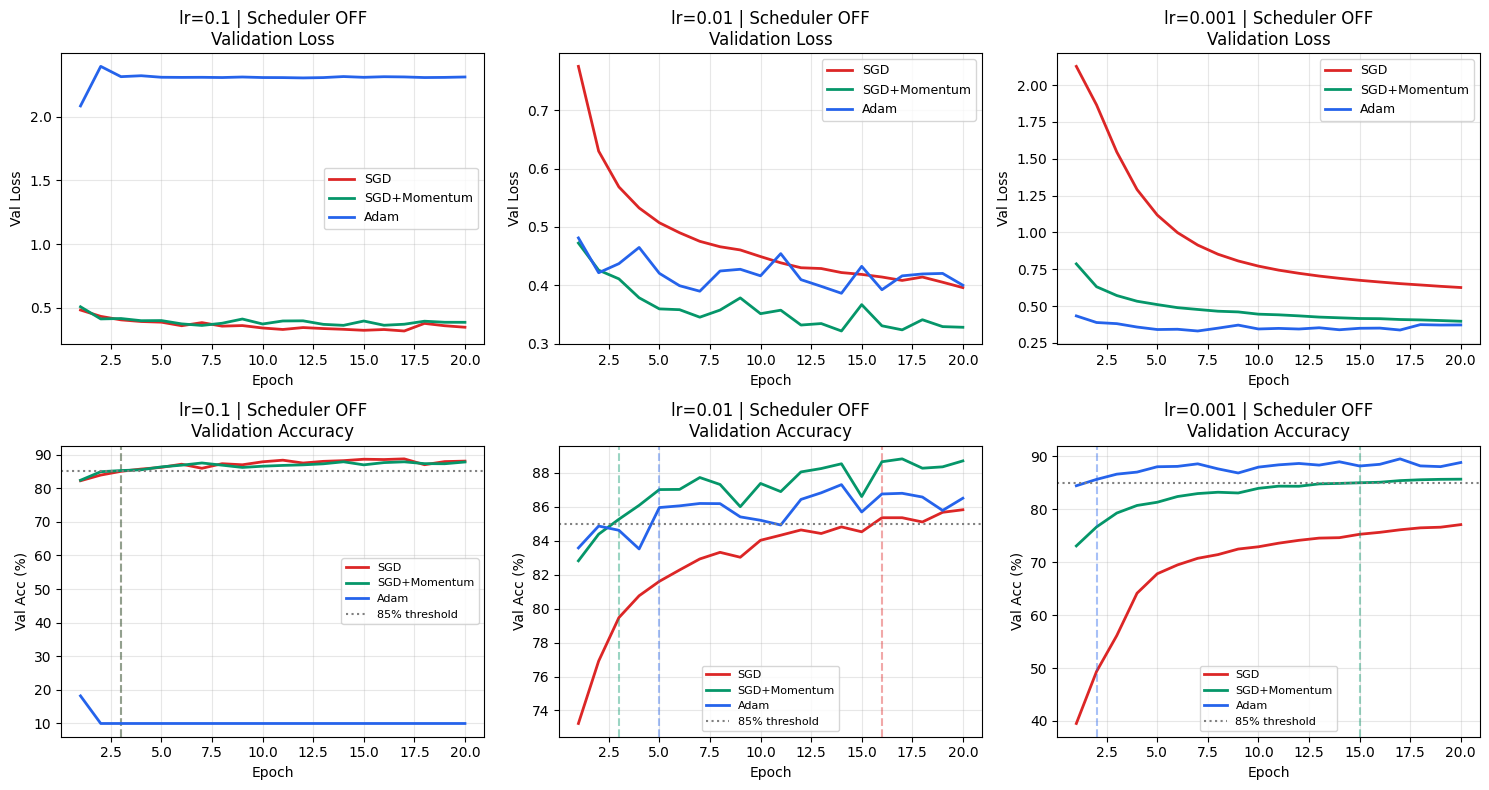

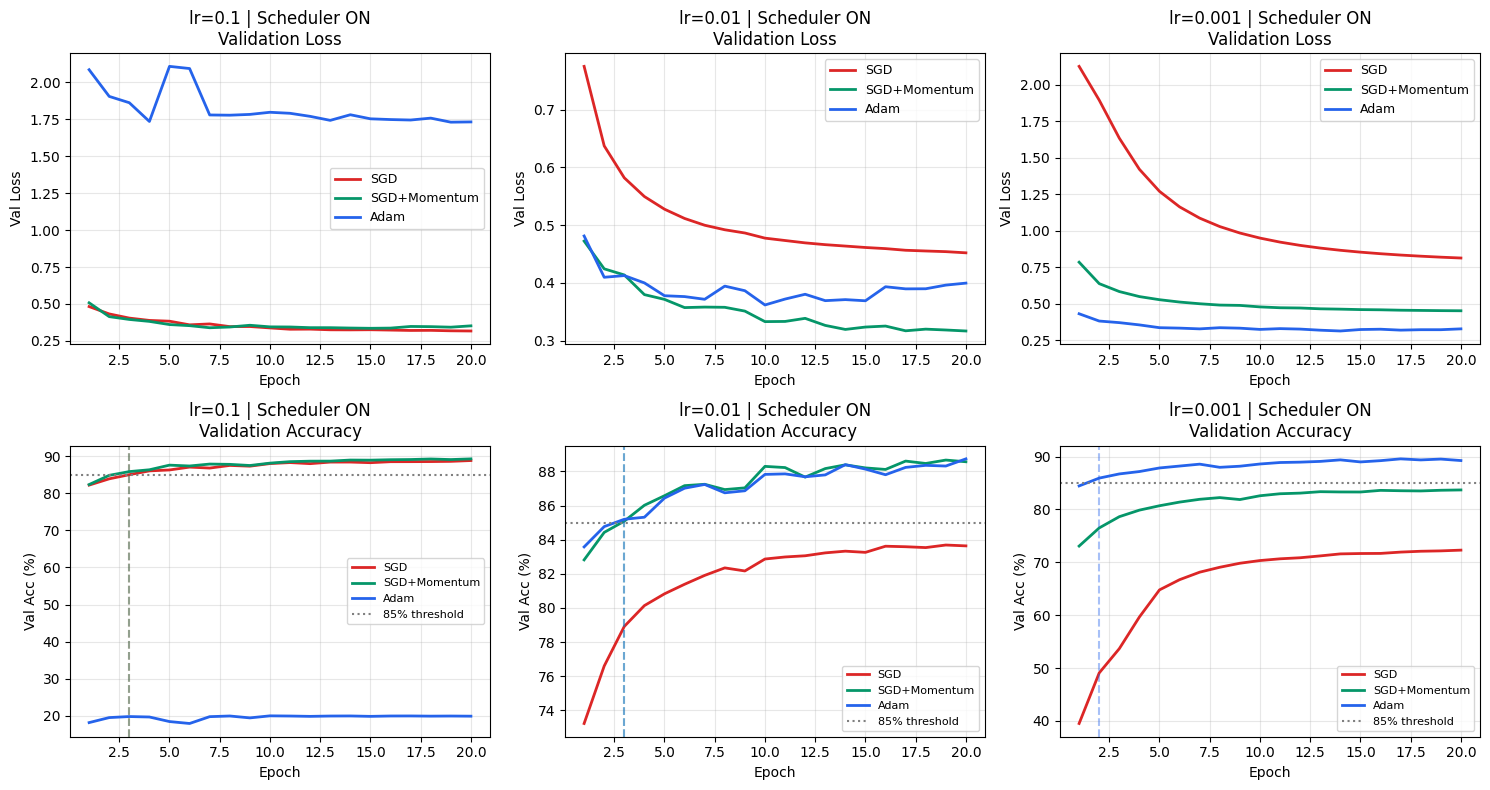

In [ ]:
# 시각화 1: 세 Optimizer를 같은 축에 비교

def plot_optimizer_overlay(records, use_sched: bool, cfg: ExpCConfig):
    color_map = {"SGD": "#DC2626", "SGD+Momentum": "#059669", "Adam": "#2563EB"}
    n_lr = len(cfg.lr_candidates)

    fig, axes = plt.subplots(2, n_lr, figsize=(5 * n_lr, 8))
    sched_tag = "Scheduler ON" if use_sched else "Scheduler OFF"

    for col, lr in enumerate(cfg.lr_candidates):
        # Val Loss
        ax_loss = axes[0, col]
        for opt_name in cfg.optimizer_names:
            key = (opt_name, lr, use_sched)
            if key not in records:
                continue
            rec = records[key]
            ax_loss.plot(range(1, len(rec.val_loss) + 1), rec.val_loss,
                         label=opt_name, color=color_map[opt_name], linewidth=2)
        ax_loss.set_title(f"lr={lr} | {sched_tag}\nValidation Loss")
        ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Val Loss")
        ax_loss.legend(fontsize=9); ax_loss.grid(alpha=0.3)

        # Val Accuracy
        ax_acc = axes[1, col]
        for opt_name in cfg.optimizer_names:
            key = (opt_name, lr, use_sched)
            if key not in records:
                continue
            rec = records[key]
            ax_acc.plot(range(1, len(rec.val_acc) + 1),
                        [a*100 for a in rec.val_acc],
                        label=opt_name, color=color_map[opt_name], linewidth=2)
            if rec.convergence_epoch:
                ax_acc.axvline(x=rec.convergence_epoch, color=color_map[opt_name],
                               linestyle="--", alpha=0.4)
        ax_acc.axhline(y=cfg.convergence_acc * 100, color="gray", linestyle=":",
                       label=f"{cfg.convergence_acc*100:.0f}% threshold")
        ax_acc.set_title(f"lr={lr} | {sched_tag}\nValidation Accuracy")
        ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Val Acc (%)")
        ax_acc.legend(fontsize=8); ax_acc.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_optimizer_overlay(all_records, use_sched=False, cfg=CFG)
plot_optimizer_overlay(all_records, use_sched=True, cfg=CFG)

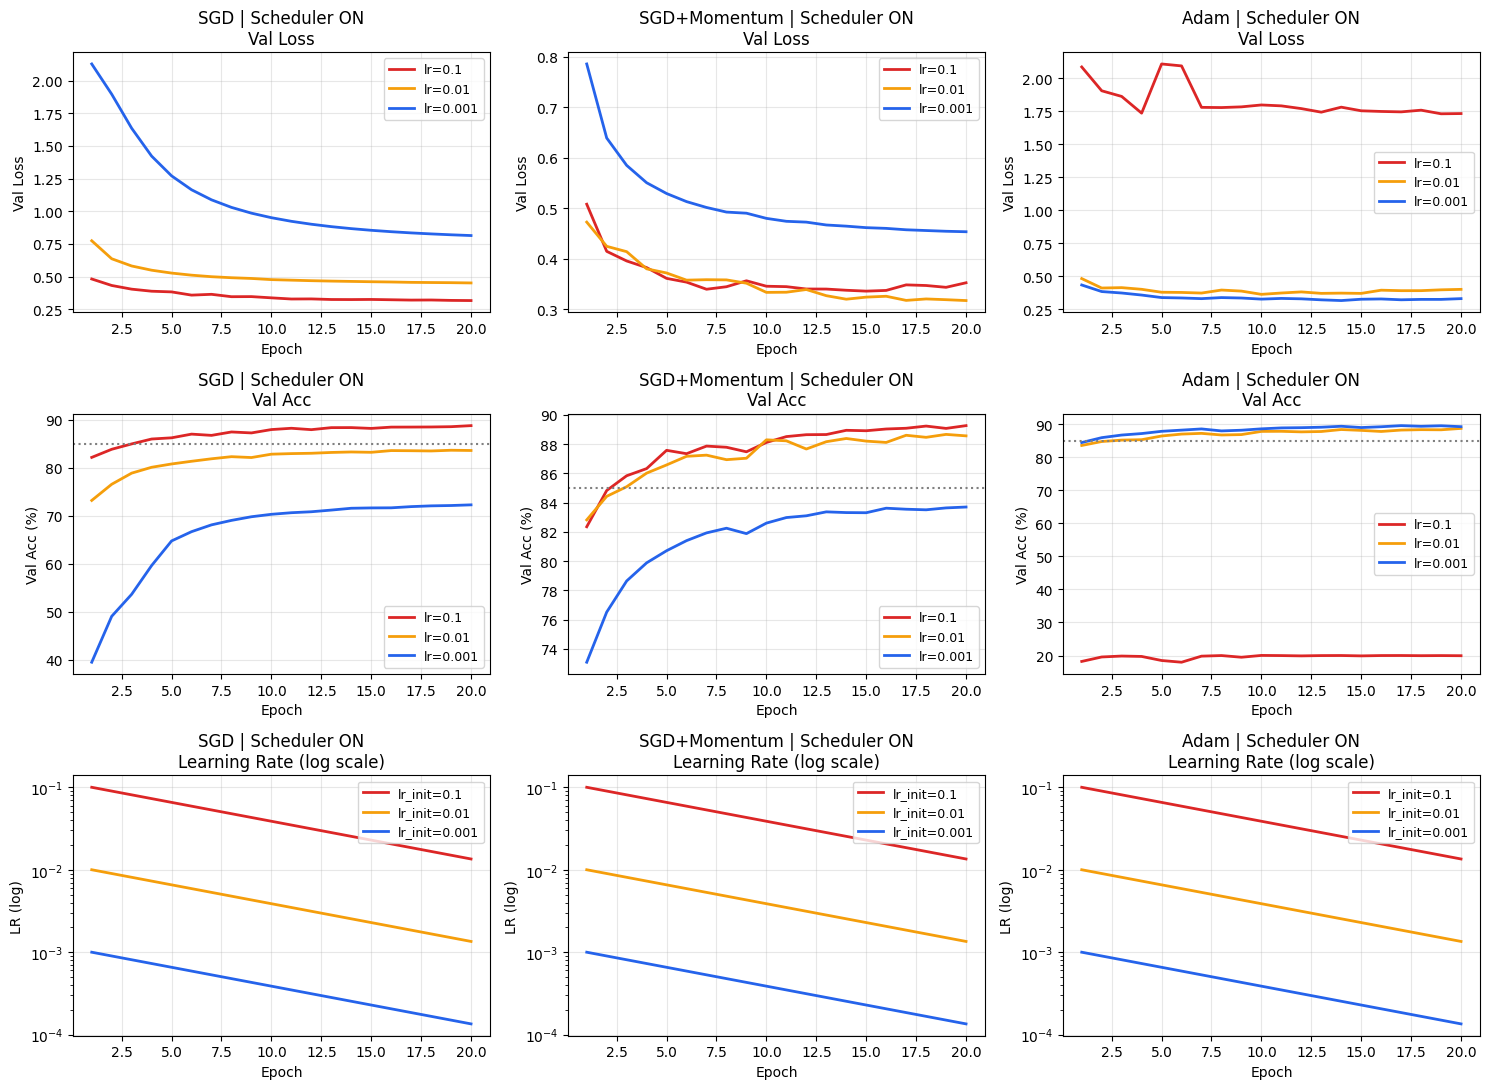

In [ ]:
# 시각화 2: 각 Optimizer 내부에서 학습률 영향

def plot_lr_effect_per_optimizer(records, use_sched: bool, cfg: ExpCConfig):
    lr_color = {0.1: "#DC2626", 0.01: "#F59E0B", 0.001: "#2563EB"}
    sched_tag = "Scheduler ON" if use_sched else "Scheduler OFF"
    n_opt = len(cfg.optimizer_names)

    fig, axes = plt.subplots(3, n_opt, figsize=(5 * n_opt, 11))

    for col, opt_name in enumerate(cfg.optimizer_names):
        # Loss
        ax = axes[0, col]
        for lr in cfg.lr_candidates:
            key = (opt_name, lr, use_sched)
            if key not in records: continue
            rec = records[key]
            ax.plot(range(1, len(rec.val_loss) + 1), rec.val_loss,
                    label=f"lr={lr}", color=lr_color[lr], linewidth=2)
        ax.set_title(f"{opt_name} | {sched_tag}\nVal Loss")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Val Loss")
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

        # Accuracy
        ax = axes[1, col]
        for lr in cfg.lr_candidates:
            key = (opt_name, lr, use_sched)
            if key not in records: continue
            rec = records[key]
            ax.plot(range(1, len(rec.val_acc) + 1),
                    [a*100 for a in rec.val_acc],
                    label=f"lr={lr}", color=lr_color[lr], linewidth=2)
        ax.axhline(y=cfg.convergence_acc * 100, color="gray", linestyle=":")
        ax.set_title(f"{opt_name} | {sched_tag}\nVal Acc")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Val Acc (%)")
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

        # Learning Rate 추이
        ax = axes[2, col]
        for lr in cfg.lr_candidates:
            key = (opt_name, lr, use_sched)
            if key not in records: continue
            rec = records[key]
            ax.plot(range(1, len(rec.lr_track) + 1), rec.lr_track,
                    label=f"lr_init={lr}", color=lr_color[lr], linewidth=2)
        ax.set_yscale("log")
        ax.set_title(f"{opt_name} | {sched_tag}\nLearning Rate (log scale)")
        ax.set_xlabel("Epoch"); ax.set_ylabel("LR (log)")
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_lr_effect_per_optimizer(all_records, use_sched=True, cfg=CFG)

Train vs Val 비교 (lr=0.01, Scheduler OFF)


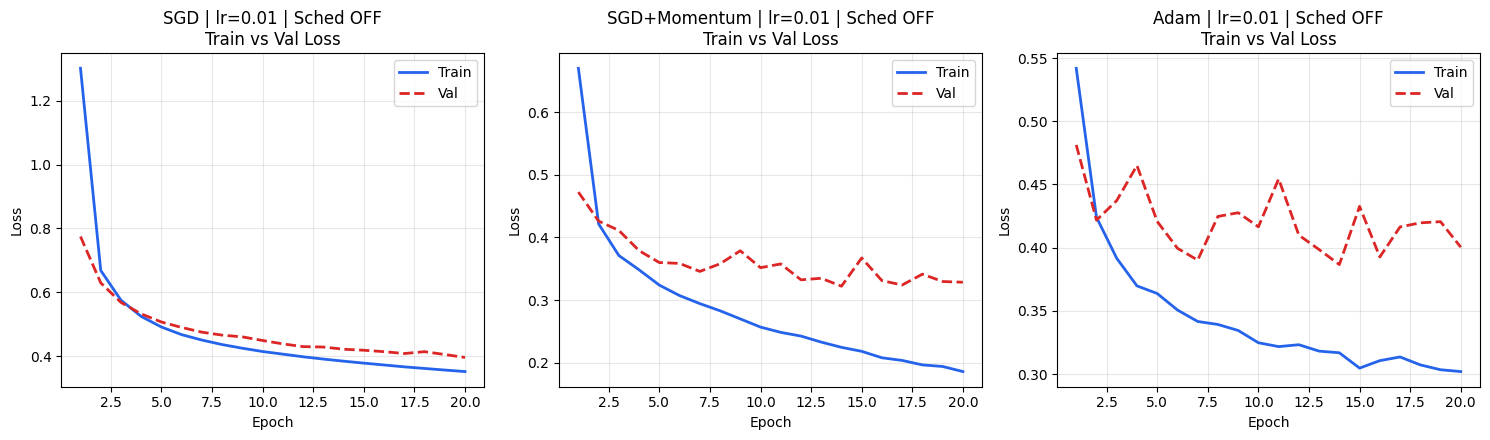

In [ ]:
# 시각화 3: Train vs Val 곡선 비교 (과적합 확인)

def plot_train_val_comparison(records, lr_pick: float, use_sched: bool, cfg: ExpCConfig):
    n_opt = len(cfg.optimizer_names)
    fig, axes = plt.subplots(1, n_opt, figsize=(5 * n_opt, 4.5))

    sched_tag = "Sched ON" if use_sched else "Sched OFF"

    for col, opt_name in enumerate(cfg.optimizer_names):
        key = (opt_name, lr_pick, use_sched)
        if key not in records: continue
        rec = records[key]
        x = range(1, len(rec.train_loss) + 1)

        ax = axes[col]
        ax.plot(x, rec.train_loss, label="Train", color="#2563EB", linewidth=2)
        ax.plot(x, rec.val_loss, label="Val", color="#DC2626",
                linewidth=2, linestyle="--")
        ax.set_title(f"{opt_name} | lr={lr_pick} | {sched_tag}\nTrain vs Val Loss")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


print("Train vs Val 비교 (lr=0.01, Scheduler OFF)")
plot_train_val_comparison(all_records, lr_pick=0.01, use_sched=False, cfg=CFG)

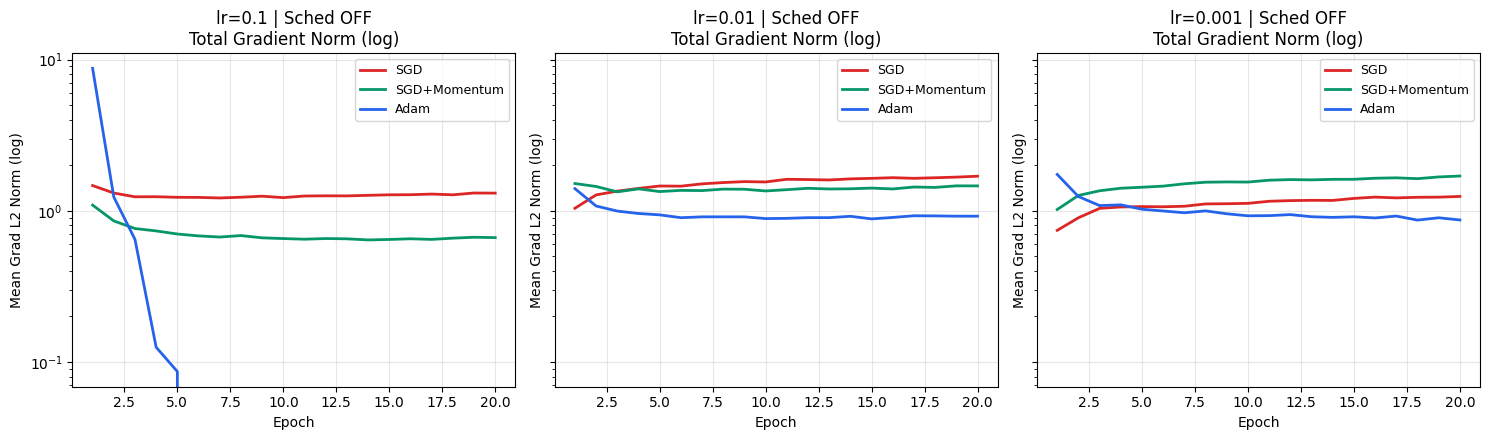

In [ ]:
# 시각화 4: 전체 Gradient L2 norm 추이 (epoch별 평균)

def plot_grad_norm_total(records, use_sched: bool, cfg: ExpCConfig):
    color_map = {"SGD": "#DC2626", "SGD+Momentum": "#059669", "Adam": "#2563EB"}
    n_lr = len(cfg.lr_candidates)
    sched_tag = "Sched ON" if use_sched else "Sched OFF"

    fig, axes = plt.subplots(1, n_lr, figsize=(5 * n_lr, 4.5), sharey=True)

    for col, lr in enumerate(cfg.lr_candidates):
        ax = axes[col]
        for opt_name in cfg.optimizer_names:
            key = (opt_name, lr, use_sched)
            if key not in records: continue
            rec = records[key]
            ax.plot(range(1, len(rec.grad_norm_total) + 1), rec.grad_norm_total,
                    label=opt_name, color=color_map[opt_name], linewidth=2)
        ax.set_yscale("log")
        ax.set_title(f"lr={lr} | {sched_tag}\nTotal Gradient Norm (log)")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Mean Grad L2 Norm (log)")
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_grad_norm_total(all_records, use_sched=False, cfg=CFG)

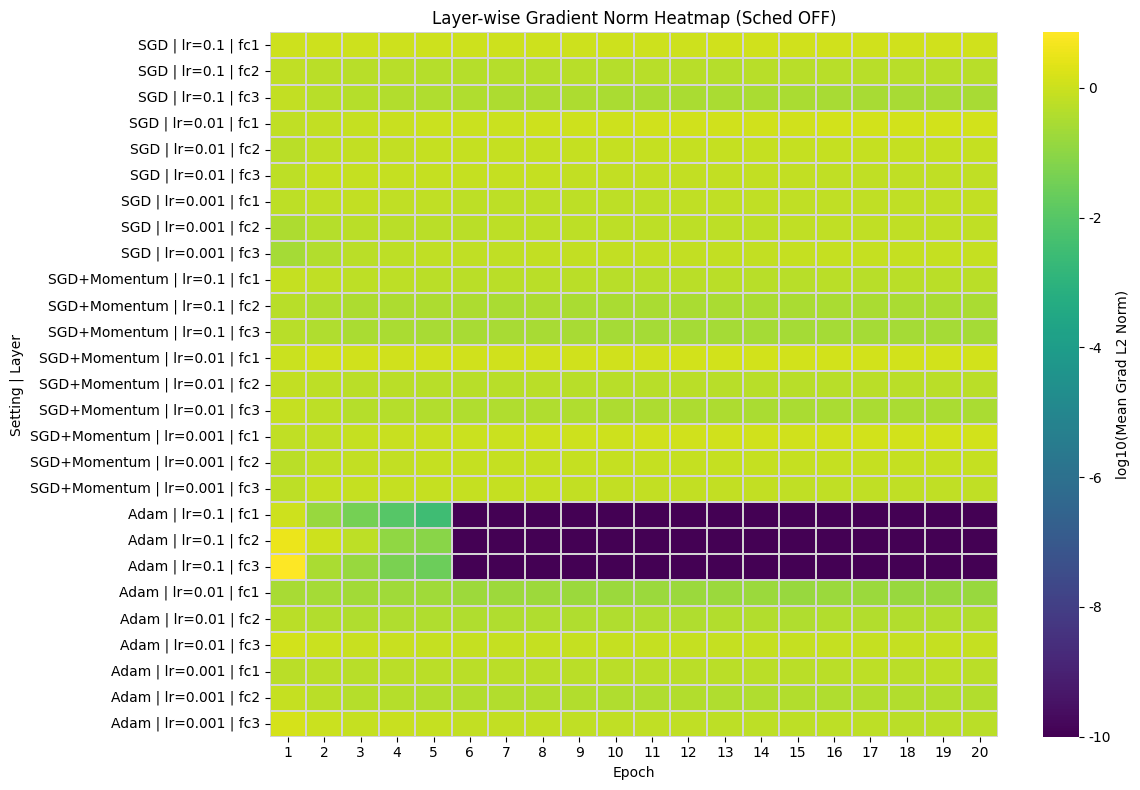

In [ ]:
# 시각화 5: 레이어별 Gradient L2 norm 히트맵

def plot_layer_grad_heatmap(records, use_sched: bool, cfg: ExpCConfig):
    heat_data = []
    row_labels = []
    sched_tag = "Sched ON" if use_sched else "Sched OFF"

    for opt_name in cfg.optimizer_names:
        for lr in cfg.lr_candidates:
            key = (opt_name, lr, use_sched)
            if key not in records: continue
            rec = records[key]
            for layer_name in ["fc1", "fc2", "fc3"]:
                series = rec.grad_norm_per_layer[layer_name]
                padded = series + [np.nan] * (cfg.n_epochs - len(series))
                heat_data.append(padded[:cfg.n_epochs])
                row_labels.append(f"{opt_name} | lr={lr} | {layer_name}")

    if not heat_data:
        print("히트맵 데이터 없음")
        return

    heat_np = np.array(heat_data)
    heat_log = np.log10(heat_np + 1e-10)

    fig, ax = plt.subplots(figsize=(max(12, cfg.n_epochs * 0.35),
                                     max(8, len(row_labels) * 0.22 + 2)))
    sns.heatmap(heat_log, cmap="viridis",
                cbar_kws={"label": "log10(Mean Grad L2 Norm)"},
                yticklabels=row_labels,
                xticklabels=range(1, cfg.n_epochs + 1) if cfg.n_epochs <= 50 else False,
                linewidths=0.2, linecolor="lightgray", ax=ax)
    ax.set_title(f"Layer-wise Gradient Norm Heatmap ({sched_tag})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Setting | Layer")
    plt.tight_layout()
    plt.show()


plot_layer_grad_heatmap(all_records, use_sched=False, cfg=CFG)

In [ ]:
# 정량 비교표 4: Optimizer별 최고 성능 요약

def summarize_best_per_optimizer(records, cfg: ExpCConfig):
    summary = []
    for opt_name in cfg.optimizer_names:
        best_acc = -1.0
        best_combo = None
        best_rec = None

        for lr in cfg.lr_candidates:
            for use_sched in cfg.scheduler_options:
                key = (opt_name, lr, use_sched)
                if key not in records: continue
                acc = records[key].val_acc[-1] * 100
                if acc > best_acc:
                    best_acc = acc
                    best_combo = (lr, use_sched)
                    best_rec = records[key]

        if best_rec is None: continue

        tail = best_rec.val_loss[cfg.n_epochs // 2:]
        stability = np.std(tail) if len(tail) >= 2 else float('nan')

        summary.append({
            "Optimizer": opt_name,
            "최적 LR": best_combo[0],
            "Scheduler": "ON" if best_combo[1] else "OFF",
            "최종 정확도 (%)": f"{best_acc:.2f}",
            "수렴 epoch": (best_rec.convergence_epoch
                          if best_rec.convergence_epoch else f">{cfg.n_epochs}"),
            "안정성 (Val Loss Std)": f"{stability:.4f}"
        })
    return pd.DataFrame(summary)


print("\n" + "="*75)
print("Optimizer별 최고 성능 요약 ")
print("="*75)
display(summarize_best_per_optimizer(all_records, CFG))


Optimizer별 최고 성능 요약 


,Optimizer,최적 LR,Scheduler,최종 정확도 (%),수렴 epoch,안정성 (Val Loss Std)
0,SGD,0.100,ON,88.82,3,0.0040
1,SGD+Momentum,0.100,ON,89.27,3,0.0052
2,Adam,0.001,ON,89.26,2,0.0046
